# Análisis y predicción del desempleo en Costa Rica mediante econometría y Machine Learning

## Autor
Ariel Mora Umaña

## Descripción general

El presente proyecto analiza la relación entre desempleo, inflación y crecimiento económico en Costa Rica utilizando herramientas de econometría y Machine Learning en Python.

El objetivo principal es:
- comprender las relaciones entre variables macroeconómicas,
- evaluar capacidad explicativa,
- y comparar distintos modelos predictivos.

El proyecto integra:
- extracción automatizada de datos mediante API,
- análisis exploratorio,
- regresión econométrica,
- modelos predictivos,
- y comparación de desempeño.

---

## Preguntas de investigación

1. ¿Qué relación existe entre desempleo, inflación y crecimiento del PIB en Costa Rica?
2. ¿Qué tan bien puede predecirse el desempleo utilizando modelos de Machine Learning?
3. ¿Un modelo complejo como Random Forest supera a modelos lineales con memoria temporal?

---

## Variables utilizadas

| Variable | Descripción |
|---|---|
| unemployment | Desempleo (% fuerza laboral) |
| inflation | Inflación anual (%) |
| gdp_growth | Crecimiento anual del PIB (%) |

---

## Herramientas utilizadas

- Python
- pandas
- numpy
- requests
- matplotlib
- seaborn
- statsmodels
- scikit-learn

In [ ]:
# Se cargan las librerías necesarias para el análisis de datos, visualización y modelado.
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import sklearn 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import os

# Crear carpeta outputs automáticamente
os.makedirs("outputs", exist_ok=True)

# Configuración visual
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")

# 1. Extracción de datos desde la API del Banco Mundial

En esta sección se descargan automáticamente los datos macroeconómicos desde la API pública del Banco Mundial.

## Indicadores utilizados

| Indicador | Código API |
|---|---|
| Desempleo | SL.UEM.TOTL.ZS |
| Inflación | FP.CPI.TOTL.ZG |
| Crecimiento PIB | NY.GDP.MKTP.KD.ZG |

---

## Importancia del uso de APIs

Las APIs permiten:
- automatizar procesos,
- trabajar con datos actualizados,
- construir proyectos reproducibles,
- y desarrollar pipelines profesionales de ciencia de datos.

En lugar de descargar manualmente archivos Excel o CSV, los datos son obtenidos directamente desde la fuente oficial.

In [16]:
# URLs API Banco Mundial

url_unemployment = "https://api.worldbank.org/v2/country/CRI/indicator/SL.UEM.TOTL.ZS?format=json&per_page=100"

url_inflation = "https://api.worldbank.org/v2/country/CRI/indicator/FP.CPI.TOTL.ZG?format=json&per_page=100"

url_gdp = "https://api.worldbank.org/v2/country/CRI/indicator/NY.GDP.MKTP.KD.ZG?format=json&per_page=100"

In [15]:
response_unemployment = requests.get(url_unemployment)
response_inflation = requests.get(url_inflation)
response_gdp = requests.get(url_gdp)

print("Unemployment status:", response_unemployment.status_code)
print("Inflation status:", response_inflation.status_code)
print("GDP status:", response_gdp.status_code)

Unemployment status: 200
Inflation status: 200
GDP status: 200


## Interpretación

El código de estado `200` indica que la conexión con la API fue exitosa y que los datos fueron obtenidos correctamente.

Esto confirma:
- acceso exitoso a la fuente oficial,
- funcionamiento correcto de la solicitud HTTP,
- y disponibilidad de los datos para el análisis.

# 2. Construcción de DataFrames

Los datos descargados desde la API se encuentran en formato JSON.

Por esta razón:
- se recorren los registros,
- se extraen años y valores,
- y posteriormente se construyen DataFrames estructurados para el análisis.

---

 ¿Por qué se utiliza `rows = []`?

Se utiliza una lista vacía llamada `rows` para almacenar temporalmente cada observación antes de convertirla en DataFrame.

Cada iteración agrega:
- el año,
- y el valor correspondiente del indicador.

Posteriormente:
- pandas transforma la lista en una estructura tabular.

In [14]:
data_unemployment = response_unemployment.json()
data_inflation = response_inflation.json()
data_gdp = response_gdp.json()

In [17]:
rows = []

for item in data_unemployment[1]:
    if item["value"] is not None:
        rows.append({
            "year": int(item["date"]),
            "unemployment": item["value"]
        })

df_unemployment = pd.DataFrame(rows).sort_values("year")

df_unemployment.head()

,year,unemployment
34,1991,5.37
33,1992,3.93
32,1993,3.95
31,1994,4.05
30,1995,5.18


In [18]:
rows = []

for item in data_inflation[1]:
    if item["value"] is not None:
        rows.append({
            "year": int(item["date"]),
            "inflation": item["value"]
        })

df_inflation = pd.DataFrame(rows).sort_values("year")

df_inflation.head()

,year,inflation
64,1960,0.790206
63,1961,2.430794
62,1962,2.677860
61,1963,2.931618
60,1964,3.324033


In [22]:
rows = []

for item in data_gdp[1]:
    if item["value"] is not None:
        rows.append({
            "year": int(item["date"]),
            "gdp_growth": item["value"]
        })

df_gdp = pd.DataFrame(rows).sort_values("year")

# 3. Construcción del dataset final

En esta etapa:
- se unen los tres DataFrames,
- se construye un único dataset,
- y se preparan los datos para el análisis econométrico y predictivo.

La variable de unión es:
- `year`

# 2. Se unificam los dataset 

En esta etapa:
- se unen los tres DataFrames,
- se eliminan valores faltantes,
- y se construye el dataset final de análisis.

In [23]:
df = df_unemployment.merge(df_inflation, on="year")
df = df.merge(df_gdp, on="year")

df = df.sort_values("year").reset_index(drop=True)

df.head()

,year,unemployment,inflation,gdp_growth
0,1991,5.37,28.709291,2.265655
1,1992,3.93,21.791169,9.201104
2,1993,3.95,9.778601,7.097191
3,1994,4.05,13.534469,4.519028
4,1995,5.18,23.186498,4.153953


## Interpretación

El dataset final contiene:
- desempleo,
- inflación,
- y crecimiento del PIB
para cada año disponible.

Una vez convertido y estructurado el set de datos es posible:
- análisis estadístico,
- regresiones,
- y modelos de Machine Learning.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          34 non-null     int64  
 1   unemployment  34 non-null     float64
 2   inflation     34 non-null     float64
 3   gdp_growth    34 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.2 KB


In [25]:
df.describe()

,year,unemployment,inflation,gdp_growth
count,34.000000,34.000000,34.000000,34.000000
mean,2007.500000,7.378971,8.848744,4.226852
std,9.958246,2.833471,6.972331,2.503824
min,1991.000000,3.930000,-0.412853,-4.273354
25%,1999.250000,5.447500,2.789699,3.503905
50%,2007.500000,6.701500,9.262383,4.265996
75%,2015.750000,8.392500,12.150936,5.054589
max,2024.000000,16.432000,28.709291,9.201104


# 3. Análisis exploratorio de datos

El análisis exploratorio permite:
- identificar patrones,
- observar tendencias,
- detectar posibles relaciones entre variables,
- y comprender mejor la estructura del dataset.

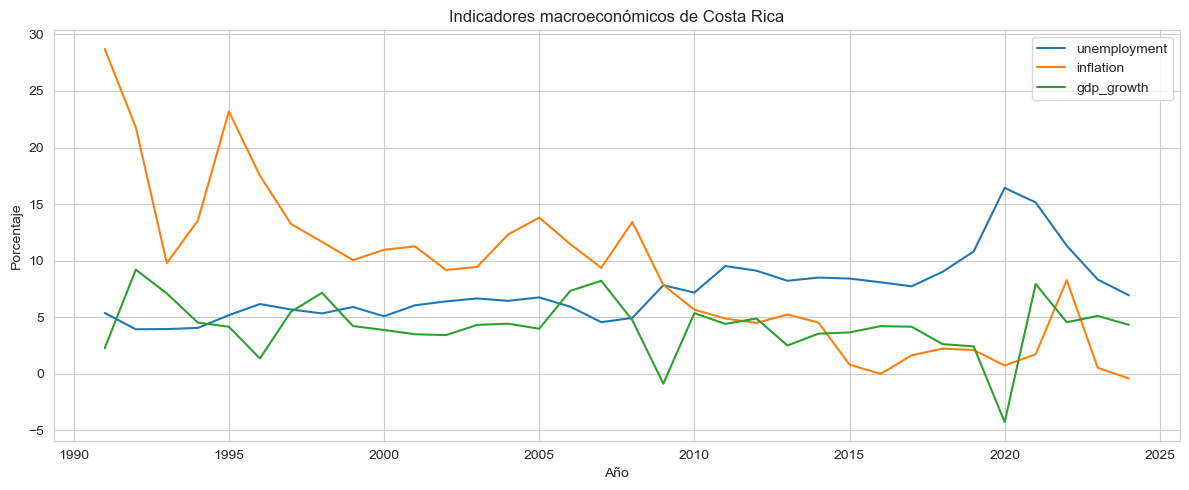

In [26]:
df.set_index("year")[["unemployment", "inflation", "gdp_growth"]].plot(figsize=(12,5))

plt.title("Indicadores macroeconómicos de Costa Rica")
plt.ylabel("Porcentaje")
plt.xlabel("Año")

plt.tight_layout()

plt.savefig("outputs/serie_temporal.png", dpi=300, bbox_inches="tight")

plt.show()

## Interpretación

El gráfico temporal permite observar:
- variaciones en desempleo,
- cambios en inflación,
- y fluctuaciones del crecimiento económico a través del tiempo.

Asimismo:
- pueden identificarse períodos de mayor volatilidad económica.

## Matriz de correlación

La matriz de correlación permite medir:
- dirección de la relación,
- intensidad de asociación lineal,
- y posibles patrones entre variables.

Valores:
- positivos → relación directa,
- negativos → relación inversa,
- cercanos a 0 → baja relación lineal.
La variable temporal (`year`) se excluye para evitar interpretaciones incorrectas.

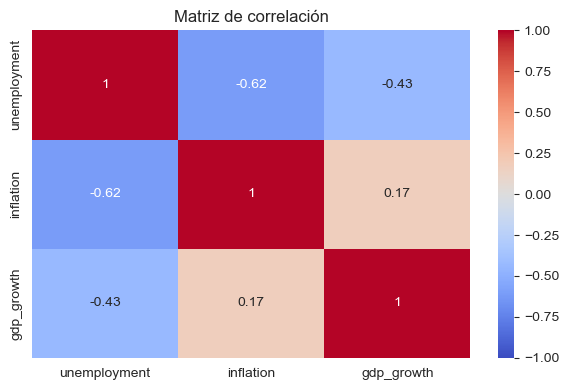

In [27]:
corr_matrix = df.drop(columns=["year"]).corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación")

plt.tight_layout()

plt.savefig("outputs/matriz_correlacion.png", dpi=300, bbox_inches="tight")

plt.show()

## Gráficos de dispersión

Los gráficos de dispersión permiten visualizar:
- la dirección de las relaciones,
- posibles tendencias,
- y comportamientos no lineales.

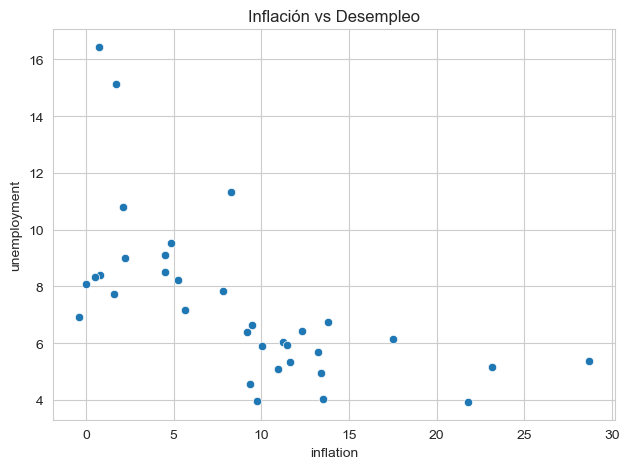

In [28]:
sns.scatterplot(
    x="inflation",
    y="unemployment",
    data=df
)

plt.title("Inflación vs Desempleo")

plt.tight_layout()

plt.savefig("outputs/scatter_inflation_unemployment.png", dpi=300, bbox_inches="tight")

plt.show()

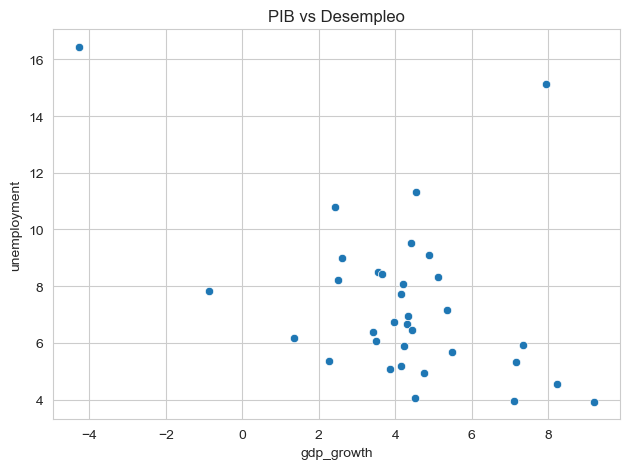

In [29]:
sns.scatterplot(
    x="gdp_growth",
    y="unemployment",
    data=df
)

plt.title("PIB vs Desempleo")

plt.tight_layout()

plt.savefig("outputs/scatter_gdp_unemployment.png", dpi=300, bbox_inches="tight")

plt.show()

## Interpretación

El gráfico sugiere una relación negativa entre crecimiento económico y desempleo.

En términos generales:
- mayores tasas de crecimiento económico tienden a asociarse con menores niveles de desempleo que es un aspecto basico en la teoria macroeconomica.

# 4. Regresión econométrica (OLS)

Se estima un modelo de regresión lineal múltiple utilizando OLS (Ordinary Least Squares).

## Variable dependiente
- unemployment

## Variables independientes
- inflation
- gdp_growth

---

## Objetivo

Evaluar:
- dirección de las relaciones,
- magnitud de los efectos,
- significancia estadística,
- y capacidad explicativa del modelo.

In [30]:
X = df[["inflation", "gdp_growth"]]
y = df["unemployment"]

X_const = sm.add_constant(X)

model_ols = sm.OLS(y, X_const).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     15.06
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.69e-05
Time:                        18:39:03   Log-Likelihood:                -71.606
No. Observations:                  34   AIC:                             149.2
Df Residuals:                      31   BIC:                             153.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.0226      0.796     13.847      0.0

## Interpretación del modelo OLS

Los resultados muestran:
- coeficientes negativos para inflación y crecimiento del PIB,
- indicando relaciones inversas con el desempleo.

Asimismo:
- las variables presentan significancia estadística,
- lo que sugiere que contribuyen a explicar variaciones en la variable de desempleo.

El R² indica que:
- aproximadamente la mitad de la variabilidad del desempleo es explicada por el modelo.

Esto implica:
- capacidad explicativa moderada,
- pero no perfecta.

# 8. Machine Learning y validación temporal

El objetivo del Machine Learning en este proyecto es:
- evaluar capacidad predictiva.

---

## ¿Por qué usar validación temporal?

En series temporales:
- el orden cronológico importa,
- y no debe utilizarse información futura para predecir el pasado.

Por esta razón:
- el modelo se entrena con datos antiguos,
- y se evalúa con datos recientes.

Esto evita fuga de información temporal.

In [31]:
def temporal_split(X, y, train_ratio=0.8):

    split_index = int(len(X) * train_ratio)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    return X_train, X_test, y_train, y_test

In [32]:
def evaluate_model(X, y, model):

    X_train, X_test, y_train, y_test = temporal_split(X, y)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return mae, rmse, y_test, y_pred

# 9. Modelo base de Machine Learning

El primer modelo predictivo planteado utiliza únicamente:
- inflación,
- y crecimiento del PIB.

Este modelo funciona como línea base para comparar mejoras posteriores.

---

## Objetivo

Evaluar:
- capacidad predictiva inicial,
- precisión,
- y comportamiento del modelo sin memoria temporal.

In [33]:
X_base = df[[
    "inflation",
    "gdp_growth"
]]

y_base = df["unemployment"]

base_model = LinearRegression()

mae_base, rmse_base, y_test_base, y_pred_base = evaluate_model(
    X_base,
    y_base,
    base_model
)

print("MODELO BASE")
print("MAE:", mae_base)
print("RMSE:", rmse_base)

MODELO BASE
MAE: 3.389193549019968
RMSE: 4.372122952613216


## Interpretación del modelo base

El modelo base presenta errores relativamente elevados.

Esto sugiere que:
- inflación y crecimiento económico contienen información relevante,
- pero no suficiente para capturar completamente la dinámica del desempleo.

En variables macroeconómicas:
- suele existir persistencia temporal,
- es decir, el pasado influye sobre el futuro.

Por esta razón:
- se incorporarán rezagos temporales en los siguientes modelos.

# 10. Modelo con rezago temporal (Lag1)

Las variables económicas suelen presentar:
- persistencia temporal,
- continuidad,
- y memoria histórica.

Esto significa que:
- el valor pasado del desempleo contiene información importante sobre su comportamiento futuro.

---

## ¿Qué es un rezago?

Un rezago (`lag`) representa:
- el valor pasado de una variable.

Por ejemplo:

`unemployment_lag1`
significa:
- desempleo del período anterior.

In [34]:
df_lag1 = df.copy()

df_lag1["unemployment_lag1"] = df_lag1[
    "unemployment"
].shift(1)

df_lag1 = df_lag1.dropna().reset_index(drop=True)

df_lag1.head()

,year,unemployment,inflation,gdp_growth,unemployment_lag1
0,1992,3.93,21.791169,9.201104,5.37
1,1993,3.95,9.778601,7.097191,3.93
2,1994,4.05,13.534469,4.519028,3.95
3,1995,5.18,23.186498,4.153953,4.05
4,1996,6.16,17.511452,1.350459,5.18


## Interpretación

Recalcar que la función `shift(1)` desplaza la variable una observación hacia abajo.

De esta manera:
- cada fila contiene el desempleo del año anterior,
- permitiendo incorporar memoria temporal al modelo.

In [35]:
X_lag1 = df_lag1[[
    "inflation",
    "gdp_growth",
    "unemployment_lag1"
]]

y_lag1 = df_lag1["unemployment"]

lag1_model = LinearRegression()

mae_lag1, rmse_lag1, y_test_lag1, y_pred_lag1 = evaluate_model(
    X_lag1,
    y_lag1,
    lag1_model
)

print("MODELO LAG1")
print("MAE:", mae_lag1)
print("RMSE:", rmse_lag1)

MODELO LAG1
MAE: 1.8309613363743613
RMSE: 2.077280319847372


## Interpretación del modelo Lag1

El modelo con rezago temporal mejora significativamente respecto al modelo base.

Esto indica que:
- el desempleo pasado es un predictor importante del desempleo futuro.

Asimismo:
- la reducción en MAE y RMSE evidencia una mejora en precisión predictiva.

---

## Importancia metodológica

Este resultado refleja un principio central de las series temporales:

> Las variables económicas poseen memoria temporal que resulta fundamental para el uso de modelos predictivos.

Por esta razón:
- incorporar rezagos suele mejorar desempeño predictivo.

# 11. Modelo con dos rezagos (Lag1 + Lag2)

En esta etapa se evalúa si incorporar una memoria temporal más larga mejora aún más la capacidad predictiva.

Se agregará:
- desempleo del período anterior,
- y desempleo de dos períodos atrás.

In [36]:
df_lags = df.copy()

df_lags["unemployment_lag1"] = df_lags[
    "unemployment"
].shift(1)

df_lags["unemployment_lag2"] = df_lags[
    "unemployment"
].shift(2)

df_lags = df_lags.dropna().reset_index(drop=True)

df_lags.head()

,year,unemployment,inflation,gdp_growth,unemployment_lag1,unemployment_lag2
0,1993,3.95,9.778601,7.097191,3.93,5.37
1,1994,4.05,13.534469,4.519028,3.95,3.93
2,1995,5.18,23.186498,4.153953,4.05,3.95
3,1996,6.16,17.511452,1.350459,5.18,4.05
4,1997,5.68,13.248044,5.476166,6.16,5.18


In [37]:
X_lag2 = df_lags[[
    "inflation",
    "gdp_growth",
    "unemployment_lag1",
    "unemployment_lag2"
]]

y_lag2 = df_lags["unemployment"]

lag2_model = LinearRegression()

mae_lag2, rmse_lag2, y_test_lag2, y_pred_lag2 = evaluate_model(
    X_lag2,
    y_lag2,
    lag2_model
)

print("MODELO LAG1 + LAG2")
print("MAE:", mae_lag2)
print("RMSE:", rmse_lag2)

MODELO LAG1 + LAG2
MAE: 2.0006090616815255
RMSE: 2.2144521829010695


## Interpretación del modelo Lag1 + Lag2

La incorporación de un segundo rezago no mejoró el desempeño predictivo.

Esto sugiere que:
- el desempleo más reciente contiene mayor información relevante,
- mientras que rezagos más antiguos aportan menos capacidad predictiva.

---

## Interpretación técnica

Agregar más variables no siempre mejora un modelo.

En muestras pequeñas:
- demasiadas variables pueden introducir ruido,
- aumentar complejidad,
- y deteriorar capacidad predictiva.

# 12. Modelo Random Forest

Random Forest es un algoritmo de Machine Learning basado en:
- múltiples árboles de decisión.

El modelo:
- construye numerosos árboles,
- realiza predicciones individuales,
- y posteriormente promedia los resultados.

---

## Objetivo

Capturar:
- relaciones complejas,
- patrones no lineales,
- e interacciones difíciles de modelar mediante regresión lineal.

---

## Ventajas

- Detecta relaciones no lineales.
- Reduce sobreajuste respecto a un árbol individual.
- Maneja interacciones complejas.

---

## Desventajas

- Requiere más datos.
- Menor interpretabilidad.
- Puede sobreajustarse en datasets pequeños.

In [38]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2
)

mae_rf, rmse_rf, y_test_rf, y_pred_rf = evaluate_model(
    X_lag1,
    y_lag1,
    rf_model
)

print("RANDOM FOREST")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

RANDOM FOREST
MAE: 3.350833528911567
RMSE: 4.2997703092442565


## Interpretación de Random Forest

El modelo Random Forest presentó peor desempeño que el modelo lineal con rezago.

Esto puede explicarse por:
- tamaño reducido de muestra,
- limitada cantidad de observaciones,
- y estructura relativamente simple de los datos.

---

## Interpretación metodológica

En datasets pequeños:
- modelos complejos pueden sobreajustarse,
- aprendiendo ruido en lugar de patrones reales.

Por esta razón:
- modelos lineales simples bien especificados
pueden superar algoritmos más sofisticados.

# 13. Comparación general de modelos

Se comparan:
- precisión predictiva,
- error absoluto medio (MAE),
- y raíz del error cuadrático medio (RMSE).

---

## Interpretación de métricas

### MAE
Promedio absoluto del error.

Indica:
- cuántas unidades se equivoca el modelo en promedio.

---

### RMSE
Raíz del error cuadrático medio.

Penaliza más:
- errores grandes.

Menores valores indican:
- mejor desempeño predictivo.

In [39]:
comparison = pd.DataFrame({
    "Modelo": [
        "Base",
        "Lag1",
        "Lag1 + Lag2",
        "Random Forest"
    ],
    "MAE": [
        mae_base,
        mae_lag1,
        mae_lag2,
        mae_rf
    ],
    "RMSE": [
        rmse_base,
        rmse_lag1,
        rmse_lag2,
        rmse_rf
    ]
})

comparison

,Modelo,MAE,RMSE
0,Base,3.389194,4.372123
1,Lag1,1.830961,2.077280
2,Lag1 + Lag2,2.000609,2.214452
3,Random Forest,3.350834,4.299770


## Interpretación comparativa

El modelo con `Lag1` presentó el mejor desempeño general.

Esto indica que:
- la memoria temporal por medio de variables rezagadas es fundamental para predecir desempleo.

Asimismo:
- el segundo rezago no aportó mejora significativa,
- y Random Forest presentó menor precisión debido al tamaño reducido del dataset.

In [40]:
comparison.to_csv(
    "outputs/comparacion_modelos.csv",
    index=False
)

# 14. Visualización comparativa de modelos

El siguiente gráfico permite comparar visualmente los errores de cada modelo.

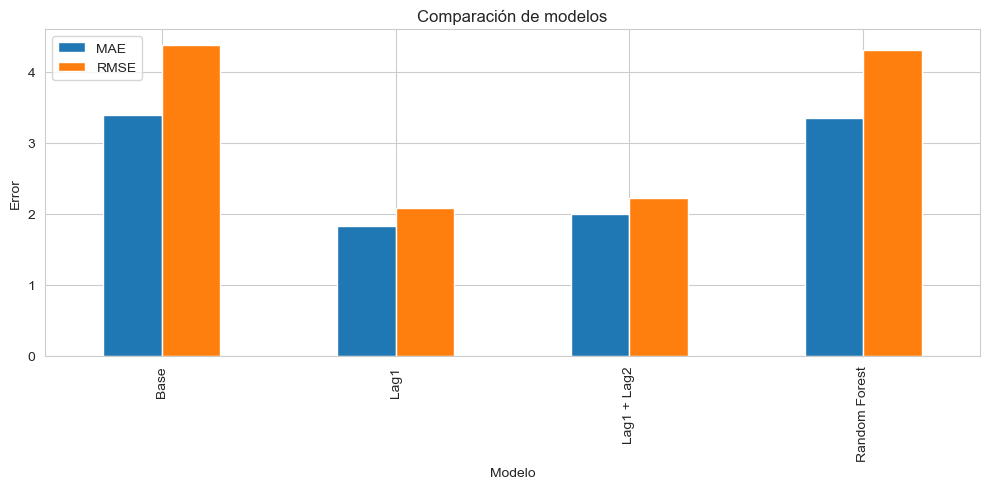

In [41]:
comparison.plot(
    x="Modelo",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparación de modelos")

plt.ylabel("Error")

plt.tight_layout()

plt.savefig(
    "outputs/comparacion_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretación

Visualmente puede observarse que:
- el modelo Lag1 posee los menores errores,
- confirmando su superioridad predictiva dentro del proyecto.

# 15. Predicción vs valores reales

Este gráfico permite evaluar:
- cercanía entre predicciones y valores reales,
- dispersión de errores,
- y comportamiento general del modelo.

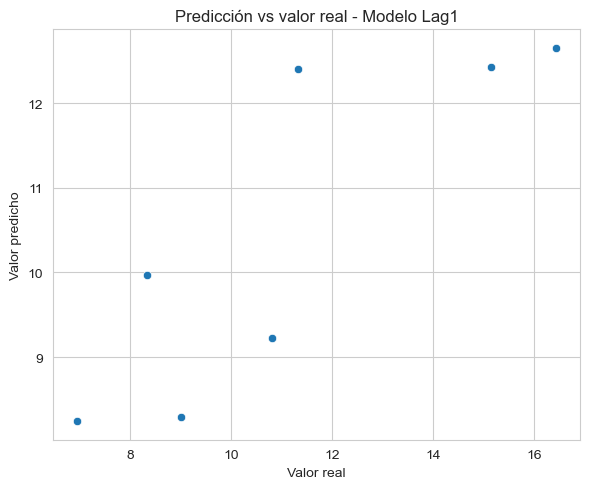

In [42]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=y_test_lag1,
    y=y_pred_lag1
)

plt.xlabel("Valor real")
plt.ylabel("Valor predicho")

plt.title("Predicción vs valor real - Modelo Lag1")

plt.tight_layout()

plt.savefig(
    "outputs/prediccion_vs_real.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretación

La cercanía entre puntos reales y predichos indica:
- capacidad razonable de predicción.

Asimismo:
- la dispersión observada refleja errores naturales presentes en los modelos económicos seleccionados.

# 16. Importancia de variables en Random Forest

Random Forest permite estimar:
- qué variables contribuyen más al proceso predictivo.

In [43]:
feature_importance = pd.DataFrame({
    "Variable": X_lag1.columns,
    "Importancia": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importancia",
    ascending=False
)

feature_importance

,Variable,Importancia
0,inflation,0.643472
2,unemployment_lag1,0.254073
1,gdp_growth,0.102454


## Interpretación

La importancia de variables muestra:
- cuáles predictores influyen más en las decisiones del modelo.

En este caso:
- la inflación y el desempleo rezagado presentan mayor relevancia predictiva.

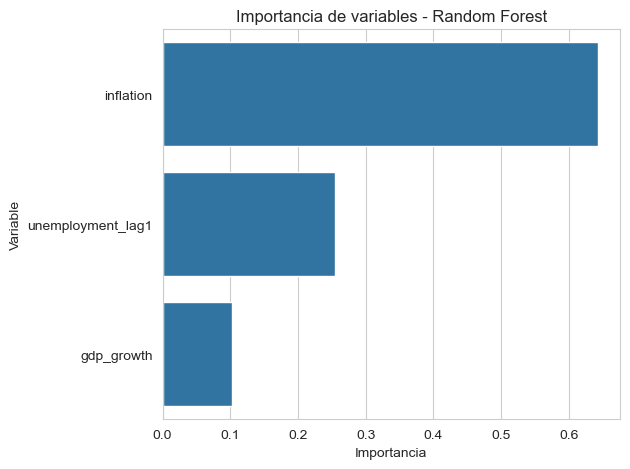

In [30]:
sns.barplot(
    x="Importancia",
    y="Variable",
    data=feature_importance
)

plt.title("Importancia de variables - Random Forest")

plt.tight_layout()

plt.savefig(
    "outputs/importancia_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17. Limitaciones del proyecto

El proyecto presenta varias limitaciones:

- tamaño reducido de muestra con n=34,
- uso de datos anuales,
- pocas variables explicativas,
- ausencia de shocks externos,
- y limitaciones propias de modelos lineales simples.

Asimismo:
- variables institucionales y políticas podrían mejorar capacidad explicativa.

# 18. Futuras líneas de investigación

El proyecto podría expandirse utilizando otros modelos como:

- Walk-Forward Validation,
- ARIMA,
- SARIMA,
- ARIMAX,
- Prophet,
- XGBoost,
- redes neuronales,
- LSTM,
- y modelos VAR econométricos.

Asimismo:
- podrían incorporarse nuevas variables:
    - tasas de interés,
    - deuda pública,
    - inversión extranjera,
    - desigualdad,
    - informalidad,
    - y variables político-institucionales.

# 19. Conclusiones finales

## Principales hallazgos

El análisis mostró:
- relaciones negativas entre desempleo e inflación,
- relaciones negativas entre desempleo y crecimiento económico,
- y evidencia estadística consistente con teoría la macroeconómica tradicional.

---

## Hallazgos predictivos

El modelo con rezago temporal (`Lag1`) presentó:
- el mejor desempeño predictivo,
- menores errores,
- y mejor equilibrio entre simplicidad y precisión.

Por otro lado:
- Random Forest no logró superar al modelo lineal,
- probablemente debido al tamaño reducido del dataset.

---

## Conclusión metodológica

El proyecto demuestra que:
- modelos simples bien especificados
pueden superar algoritmos complejos en datasets pequeños.

Asimismo:
- la incorporación de memoria temporal es fundamental en análisis económico, es deci, agregar variables rezagadas.

---

## Conclusión 

Este proyecto integra:
- econometría,
- Machine Learning,
- análisis macroeconómico,
- y ciencia de datos aplicada.

Asimismo:
- evidencia el potencial de utilizar herramientas cuantitativas para el análisis político-económico y toma de decisiones basadas en datos.

In [44]:
df.to_csv("data/df.csv", index=False)